In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from vibroglass import VibrationalSystem, VibrationalSpectra
from vibroglass.core.kernels import compute_vdos, compute_kernel
from vibroglass.analysis.structure_factor import make_IR_vector

## Vibrational Density of States

Compute the total and element-resolved VDOS for a 648-atom amorphous SiO$_2$ system.

### Initialize system and compute stochastic VDOS

In [ ]:
root = "aSiO2_648/"
omega_array = np.linspace(0.1, 250, 10000)
nstoc = 10

system = VibrationalSystem(root=root)
spectra = VibrationalSpectra(
    system, options={"hl_steps": 300, "eta": 1.0, "omega_array": omega_array}
)

# Compute stochastic VDOS
start = time.time()
VDOS = spectra.compute_stochastic_vdos(nstoc=nstoc)
end = time.time()
print(f"Haydock wall time: {end - start:.1f} s")

# Average and error bars
prefactor_error = 3
w = spectra.options.omega_array
y = np.mean([w * VDOS[i]["S"] for i in range(nstoc)], axis=0)
yerr = prefactor_error * np.std([w * VDOS[i]["S"] for i in range(nstoc)], axis=0) / np.sqrt(nstoc)
norm = np.trapezoid(y, w)
y /= norm
yerr /= norm

# Direct diagonalisation for comparison
dynmat_dense = spectra.vs.dynmat.toarray()
start = time.time()
w2, eig = np.linalg.eigh(dynmat_dense)
end = time.time()
print(f"Diagonalisation time: {end - start:.1f} s")
eta = spectra.options.eta
w_true = np.sign(w2) * np.sqrt(np.abs(w2))

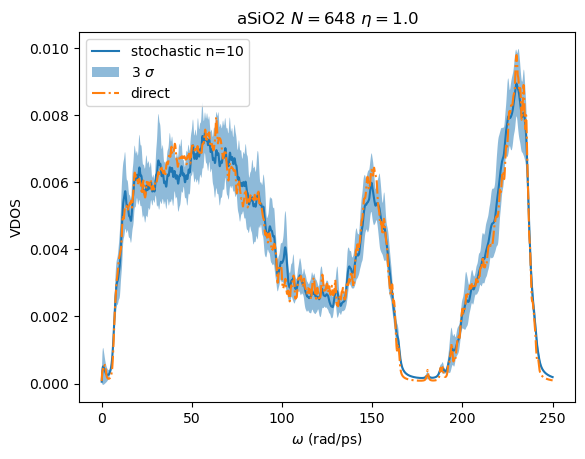

In [9]:
fig, ax = plt.subplots()

ax.plot(w, y, label="stochastic n={}".format(nstoc))
ax.fill_between(w, y + yerr, y - yerr, alpha=0.5, label=f"{prefactor_error} $\sigma$")

# vdos=compute_vdos(w_true,w,sigma=eta/2,kernel='lorentz')
# ax.plot(w,vdos,'--',label='direct Lor.')
vdos = compute_vdos(w_true, w, sigma=eta, kernel="DHO")
ax.plot(w, vdos, "-.", label="direct")  # DHO
chemical_f = spectra.vs.atoms.get_chemical_symbols()[0]
N = spectra.vs.atoms.get_global_number_of_atoms()
plt.title(f"aSiO2 $N={N}$ $\eta={eta}$")
plt.legend()
plt.ylabel("VDOS")
plt.xlabel("$\omega\mathrm{~(rad/ps)}$")
plt.show()

### Element-resolved VDOS

Project the VDOS onto individual atomic species (Si and O) to understand their contributions.

In [10]:
### Compute Stochastic VDOS per element
w = spectra.options.omega_array
VDOS_element = {}
for element in ["Si", "O"]:
    start = time.time()
    VDOS = spectra.compute_stochastic_vdos(nstoc=nstoc, element=element)
    end = time.time()
    print("Haydock wall time:{} s".format(end - start))
    y = np.mean(np.array([w * VDOS[i]["S"] for i in range(nstoc)]), axis=0)
    norm = np.trapz(y, w)
    y /= norm
    VDOS_element[element] = y

extracting VDOS for element: %s (experimental feature) Si
Number of processes used 4
Haydock wall time:37.31662082672119 s
extracting VDOS for element: %s (experimental feature) O
Number of processes used 4
Haydock wall time:40.125165700912476 s


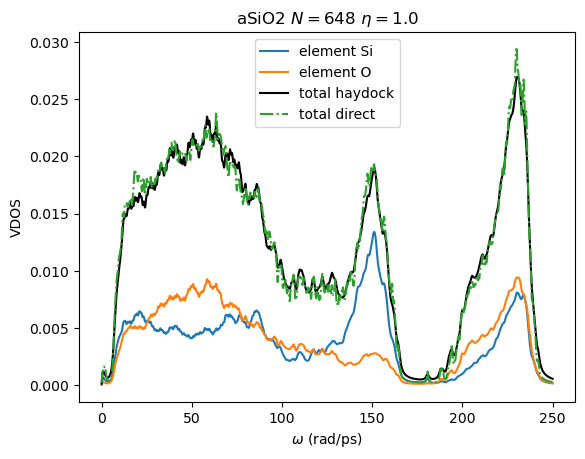

In [11]:
### Plotting
w = spectra.options.omega_array


fig, ax = plt.subplots()
for element in ["Si", "O"]:
    y = VDOS_element[element]
    ax.plot(w, y, label="element {}".format(element))
tot_vdos = VDOS_element["Si"] * 1 + VDOS_element["O"] * 2
ax.plot(w, tot_vdos, "-", label="total haydock", color="black")
ax.plot(w, vdos * 3, "-.", label="total direct")
plt.title(f"aSiO2 $N={N}$ $\eta={eta}$")
plt.legend()
plt.ylabel("VDOS")
plt.xlabel("$\omega\mathrm{~(rad/ps)}$")
plt.show()

## Infrared (IR) Spectrum

Compute the IR absorption spectrum using the Haydock recursion method and compare
with the direct diagonalisation result. Born effective charges are assigned as
Si = +3.2 and O = −1.6.

In [ ]:
# Re-initialise with slightly wider frequency range for the IR window
omega_array = np.linspace(0.1, 260, 10000)
system = VibrationalSystem(root="aSiO2_648/")
spectra = VibrationalSpectra(
    system, options={"hl_steps": 300, "eta": 1.0, "omega_array": omega_array}
)

# Haydock IR spectrum (all three Cartesian polarisations)
start = time.time()
spectrum = spectra.compute_IR_spectrum(
    polarizations=[0, 1, 2], charges_dict={"Si": 3.2, "O": -1.6}
)
end = time.time()
print(f"Haydock wall time: {end - start:.1f} s")

# Direct diagonalisation for comparison
dynmat_dense = spectra.vs.dynmat.toarray()
w2, eig = np.linalg.eigh(dynmat_dense)
w_true = np.sign(w2) * np.sqrt(np.abs(w2))

# Build IR coupling vectors
atoms = spectra.vs.atoms
phi = make_IR_vector(atoms=atoms, polarizations=[0, 1, 2], charges_dict={"Si": 3.2, "O": -1.6})

# Plot comparison for x-polarisation
thz2cm1 = 33.35641
x = spectra.options.omega_array

fig, ax = plt.subplots()
for i, pol in enumerate(["x"]):
    # Direct: project IR vector onto eigenmodes
    Z_mu = np.einsum("i,in->n", phi[i], eig)
    y_direct = np.abs(Z_mu) ** 2 / w_true
    y_direct = compute_kernel(
        w_true, y_direct, x, sigma=spectra.options.eta, kernel="lorentz", normalize=True
    )
    ax.plot(
        x * thz2cm1 / (2 * np.pi),
        y_direct * 2 * np.pi / thz2cm1,
        label=f"IR direct pol. {pol}",
        marker=".",
    )

    # Haydock result
    y_hay = spectrum[i]["S"]
    norm = np.trapezoid(y_hay, x)
    y_hay /= norm
    ax.plot(
        x * thz2cm1 / (2 * np.pi),
        y_hay * 2 * np.pi / thz2cm1,
        label=f"IR Haydock pol. {pol}",
    )

ax.set_xlabel("Frequency (cm$^{-1}$)")
ax.set_ylabel("IR (a.u.)")
ax.set_xlim(0, 1400)
ax.set_yticks([])
ax.legend()
plt.show()